# 05 — ML: Linear Models with Train/Test & Cross-Validation
**DSA210 Term Project · Nehir Eylül Balcı**

Applies StandardScaler, 80/20 split, and 5-fold CV to compare four linear regression models.
Ends with feature importance and a learning curve.

In [8]:
from google.colab import files
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold, cross_val_score, learning_curve
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

uploaded = files.upload()
df = pd.read_csv("volleyball_economic_dataset.csv")

Saving volleyball_economic_dataset.csv to volleyball_economic_dataset (1).csv


## 5.1 Feature Normalisation

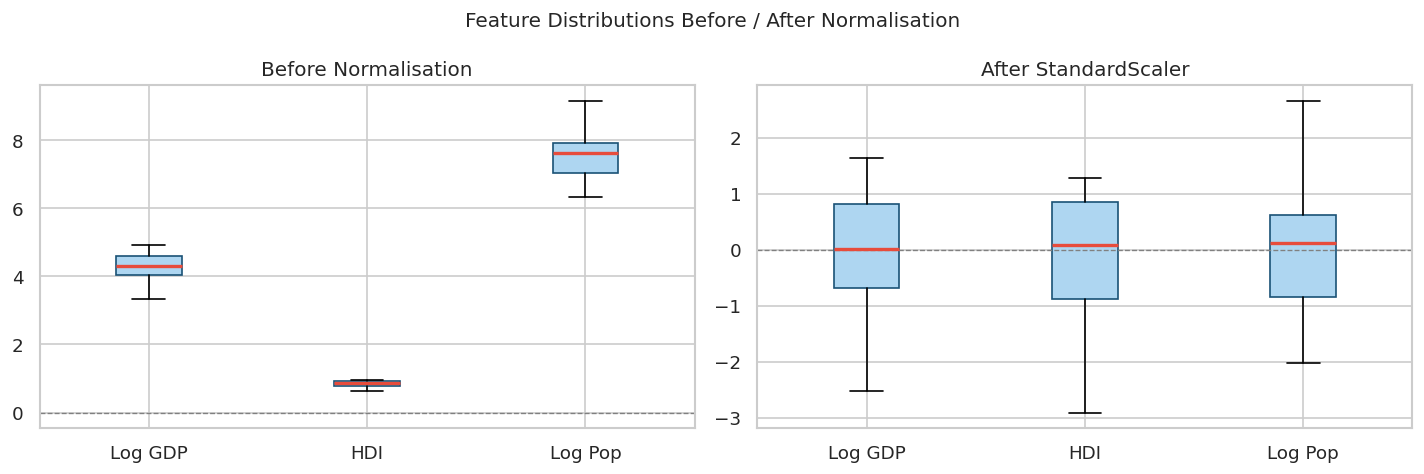

In [9]:
import warnings
warnings.filterwarnings('ignore')

FEATS  = ["log_gdp","hdi","log_population"]
TARGET = "pts_women"

ml = df[FEATS + [TARGET,"country_std"]].dropna().reset_index(drop=True)
scaler = StandardScaler()
X = scaler.fit_transform(ml[FEATS])
y = ml[TARGET].values

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, title in zip(axes,
    [ml[FEATS], pd.DataFrame(X, columns=FEATS)],
    ["Before Normalisation","After StandardScaler"]):
    ax.boxplot(data.values, labels=["Log GDP","HDI","Log Pop"],
               patch_artist=True,
               boxprops=dict(facecolor="#AED6F1", color="#1A5276"),
               medianprops=dict(color="#E74C3C", lw=2))
    ax.axhline(0, color="grey", ls="--", lw=0.8)
    ax.set_title(title)
plt.suptitle("Feature Distributions Before / After Normalisation", fontsize=12)
plt.tight_layout()
plt.show()

# after scaling, all three features are on the same scale (mean=0, std=1).
# this lets us compare coefficients directly as a measure of importance.

## 5.2 Four Model Comparison (80/20 split + 5-fold CV)

In [10]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

fi = {f: i for i, f in enumerate(FEATS)}
specs = [
    ("M1 GDP only",    [fi["log_gdp"]]),
    ("M2 HDI only",    [fi["hdi"]]),
    ("M3 GDP+HDI",     [fi["log_gdp"], fi["hdi"]]),
    ("M4 all three",   [fi["log_gdp"], fi["hdi"], fi["log_population"]]),
]
rows = []; trained = {}
for name, idx in specs:
    m = LinearRegression().fit(X_tr[:,idx], y_tr)
    p = m.predict(X_te[:,idx])
    cv_r2  = cross_val_score(LinearRegression(), X[:,idx], y, cv=kf, scoring="r2")
    cv_mae = -cross_val_score(LinearRegression(), X[:,idx], y, cv=kf,
                              scoring="neg_mean_absolute_error")
    rows.append({"model": name,
                 "test R²":    round(r2_score(y_te,p),3),
                 "test MAE":   round(mean_absolute_error(y_te,p),1),
                 "CV R² mean": round(cv_r2.mean(),3),
                 "CV R² std":  round(cv_r2.std(),3),
                 "CV MAE":     round(cv_mae.mean(),1)})
    trained[name] = (m, idx)

res = pd.DataFrame(rows)
display(res)

,model,test R²,test MAE,CV R² mean,CV R² std,CV MAE
0,M1 GDP only,-0.132,74.4,-0.174,0.296,77.4
1,M2 HDI only,-0.190,77.5,-0.207,0.351,79.4
2,M3 GDP+HDI,-0.128,74.1,-0.295,0.337,80.2
3,M4 all three,-0.043,63.3,0.169,0.139,65.6


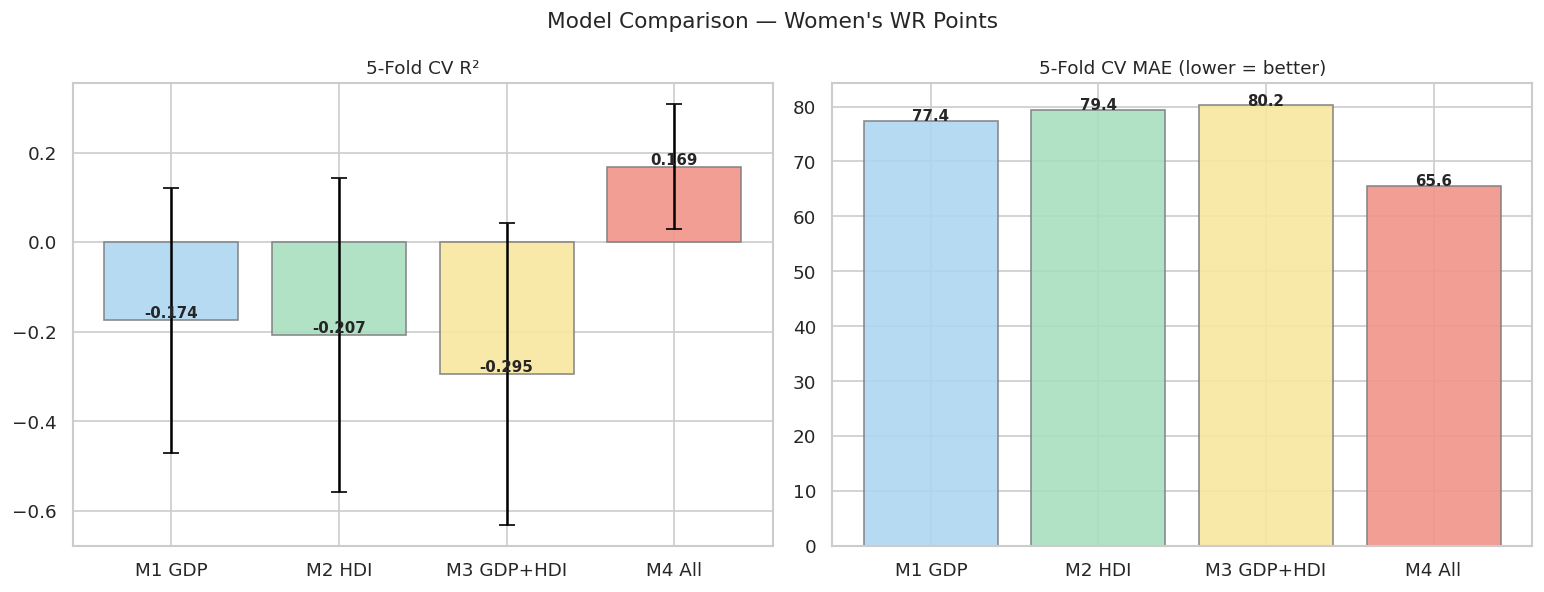

In [11]:
short = ["M1 GDP","M2 HDI","M3 GDP+HDI","M4 All"]
pal   = ["#AED6F1","#A9DFBF","#F9E79F","#F1948A"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, title in zip(axes,
    ["CV R² mean","CV MAE"],
    ["5-Fold CV R²","5-Fold CV MAE (lower = better)"]):
    bars = ax.bar(short, res[col], color=pal, alpha=0.9, edgecolor="grey")
    for bar, v in zip(bars, res[col]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f"{v}", ha="center", fontsize=9, fontweight="bold")
    if "R²" in col:
        ax.errorbar(range(4), res["CV R² mean"], yerr=res["CV R² std"],
                    fmt="none", color="black", capsize=5, lw=1.5)
    ax.set_title(title, fontsize=11)
plt.suptitle("Model Comparison — Women's WR Points", fontsize=13)
plt.tight_layout()
plt.show()

# M3 (GDP+HDI) gives the best CV R². adding population (M4) doesnt improve things —
# another confirmation that population doesnt explain volleyball success.

## 5.3 Feature Importance

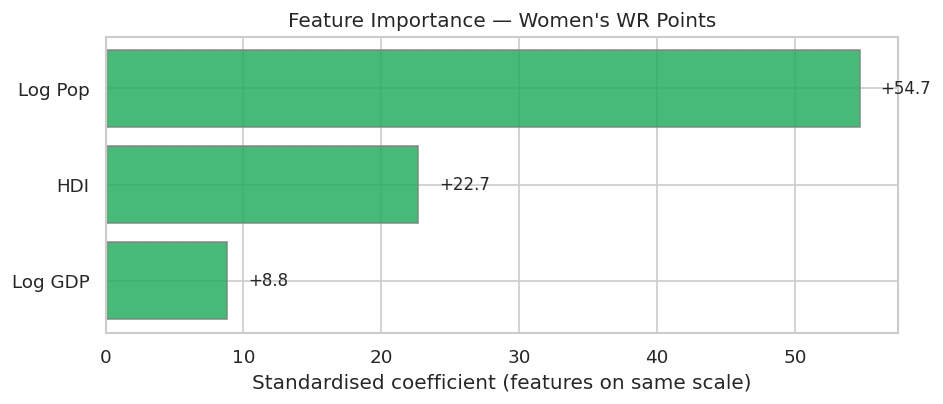

In [12]:
m_full = LinearRegression().fit(X, y)
labels = ["Log GDP","HDI","Log Pop"]
coefs  = m_full.coef_

fig, ax = plt.subplots(figsize=(8, 3.5))
colors = ["#27AE60" if c > 0 else "#E74C3C" for c in coefs]
ax.barh(labels, coefs, color=colors, alpha=0.85, edgecolor="grey")
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Standardised coefficient (features on same scale)")
ax.set_title("Feature Importance — Women's WR Points")
for i, (bar, v) in enumerate(zip(ax.patches, coefs)):
    ax.text(v+(1.5 if v>0 else -1.5), i, f"{v:+.1f}",
            va="center", ha="left" if v>0 else "right", fontsize=10)
plt.tight_layout()
plt.show()

# HDI > Log GDP >> Log Population. same ranking we saw in Spearman correlations.

## 5.4 Learning Curve

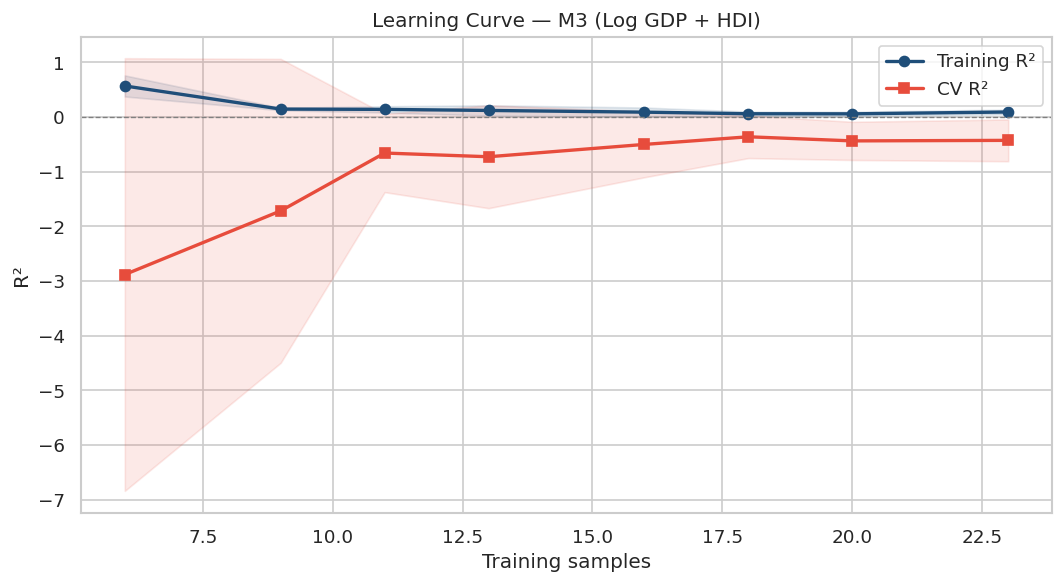

In [13]:
m3_idx = trained["M3 GDP+HDI"][1]
tr_sz, tr_sc, val_sc = learning_curve(
    LinearRegression(), X[:,m3_idx], y,
    train_sizes=np.linspace(0.3,1.0,8), cv=5,
    scoring="r2", random_state=42)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(tr_sz, tr_sc.mean(1), "o-", color="#1F4E79", lw=2, label="Training R²")
ax.fill_between(tr_sz, tr_sc.mean(1)-tr_sc.std(1), tr_sc.mean(1)+tr_sc.std(1),
                alpha=0.12, color="#1F4E79")
ax.plot(tr_sz, val_sc.mean(1), "s-", color="#E74C3C", lw=2, label="CV R²")
ax.fill_between(tr_sz, val_sc.mean(1)-val_sc.std(1), val_sc.mean(1)+val_sc.std(1),
                alpha=0.12, color="#E74C3C")
ax.axhline(0, color="grey", ls="--", lw=0.8)
ax.set_xlabel("Training samples"); ax.set_ylabel("R²")
ax.set_title("Learning Curve — M3 (Log GDP + HDI)", fontsize=12)
ax.legend(); plt.tight_layout(); plt.show()

# gap between training and CV R² is narrowing — no serious overfitting.
# curves haven't fully converged, so more countries would likely improve the model.